<img src="https://www.unad.edu.co/images/footer/logo-unad-acreditacion-min.png" width="780" height="140" align="right"/>

<p style="text-align: center;"> Course: Forecasting</p>

<p style="text-align: center;"> Course code: 203238431A </p>

<p style="text-align: center;"> Group: 02 </p>

<p style="text-align: center;"> Phase 3 Time Series Filtering and Frequency Domain
Transformations </p>

<p style="text-align: center;">  Presented by: Jerónimo Ramos Ruiz </p>

<p style="text-align: center;">  Tutor: BRAYAN ANDRU MONTENEGRO EMBUS </p>

<p style="text-align: center;"> UNIVERSIDAD NACIONAL ABIERTA Y A DISTANCIA - UNAD </p>

<p style="text-align: center;"> Medellin, March 2026</p>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error


## Exercise 1: Kalman filter implementation and convergence analysis

### Data
For this exercise we will be using the provided dataset called "Appendix 1 - xy_motion_kalman_filter_example.csv" this data set has 205 rows and we asume that the columns refer to the x and y position of an object due to the lack of headers in the CSV file provided.

To create the state vector, we asume a constant velocity asuming a random trajectory

In [2]:
# ── Loading the CSV file ──────────────────────────────────────────
# The file does not have headers so we asume the following: first column = x, second column = y
#  We will be using the file loaded in the GitHub repository so we won't have troubles
#  when we want to rerun the code
CSV_Path = 'https://raw.githubusercontent.com/Jero2110/Forecasting_Phase_3/refs/heads/main/analysis/data/Appendix%201%20-%20xy_motion_kalman_filter_example.csv'

df = pd.read_csv(CSV_Path, header=None, names=['x', 'y'])

print(f'Filas: {len(df)}  |  Columnas: {list(df.columns)}')
print()
print('Primeras 5 filas:')
display(df.head())
print()
print('Estadísticas descriptivas:')
display(df.describe().round(2))


Filas: 205  |  Columnas: ['x', 'y']

Primeras 5 filas:


,x,y
0,2.35,1.45
1,3.55,1.80
2,3.00,2.90
3,2.65,4.20
4,2.95,5.15



Estadísticas descriptivas:


,x,y
count,205.00,205.00
mean,29.23,16.10
std,13.06,6.61
min,2.35,1.45
25%,20.20,10.95
50%,32.35,16.75
75%,39.75,21.55
max,47.30,26.60


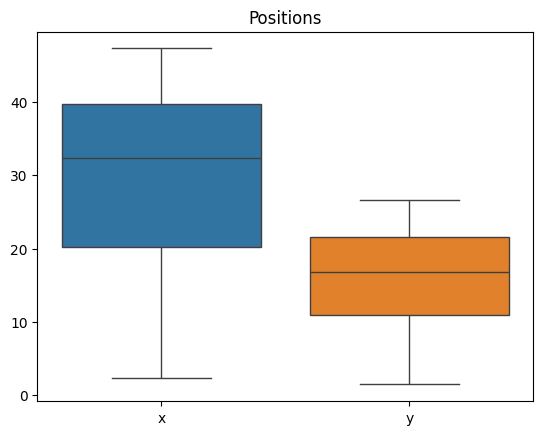

In [3]:
# We create a boxplot to find possible outliers in the data
sns.boxplot(data=df)
plt.title('Positions')
plt.show()

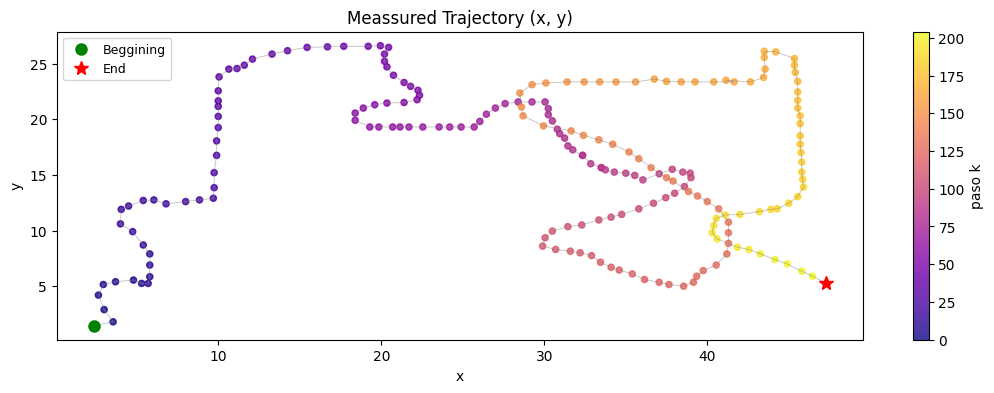

In [4]:
# ── Visual exploration of the trajectory ───────────────────────
fig, axes = plt.subplots(figsize=(13, 4))

# Scatter plot
sc = axes.scatter(df['x'], df['y'], c=range(len(df)), cmap='plasma',
                s=20, alpha=0.8)
axes.plot(df['x'], df['y'], '-', color='gray', lw=0.6, alpha=0.5)
axes.plot(df['x'].iloc[0],  df['y'].iloc[0],  'go', ms=8, label='Beggining')
axes.plot(df['x'].iloc[-1], df['y'].iloc[-1], 'r*', ms=10, label='End')
plt.colorbar(sc, ax=axes, label='paso k')
axes.set_title('Meassured Trajectory (x, y)')
axes.set_xlabel('x')
axes.set_ylabel('y')
axes.legend(fontsize=9)


In [5]:
df.isnull().sum()

,0
x,0
y,0


As we can see, the provided dataset does not appear to contain any null values ​​that could interfere with the modeling process. Also, we can see that there are no outlyers in the data as shown in the boxplot. However we can see that the movement doesn't have a defined trajectory, in fact, we can see at some point that the object start to return in his path several times.

---
### Kalman Filter


The Kalman filter addresses the general problem of trying to estimate the state of a discrete-time controlled process where we have uncertain information, and we can make an educated guess about what the system is going to do next. For this reason, Kalman filters are ideal for systems which are continuously changing.

### **System Modeling**

$$x_k = Ax_{k-1} + Bu_k + w_{k}, \quad w_k \sim \mathcal{N}(0, Q)$$
$$z_k = Hx_k + v_k, \quad v_k \sim \mathcal{N}(0, R)$$

Where:

* $x_k$: It's the state value or vector we are trying to estimate
* $x_{k-1}$: It's the previous value we estimate
* $A$: It's the $nxn$ matrix that relates the state at the previous time step $k-1$ to the state at the current step $k$, in the absence of either a driving function or process noise. 
* $B$: The $nx1$ matrix relates the optional control input ($u_k$) to the state x.
* $u_k$: Represents the control signal
* $w_{k}$: Represents the process noise.
* $Q$: Process noise covariance. 
* $z_k$: Meassurment at the time.
* $H$: The matrix $mxn$ relates the state to the measurement
* $v_{k}$: Represents the measurement noise
* $R$: Meassurment noise covariance.


### **Kalman Filter Cycle**

| Step | Equation | Description |
|------|----------|-------------|
| Prediction (state vector) | $\hat{x}^-_k = A\hat{x}_{k-1} + Bu_k$ | Initial estimate  |
| Prediction (covariance matrix) | $P^-_k = AP_{k-1}A^T + Q$ | Increase uncertainty  |
| Kalman Gain | $K_k = P^-_kH^T(HP^-_kH^T + R)^{-1}$ | Measurement weight |
| Updating (state vector) | $\hat{x}_k = \hat{x}^-_k + K_k(z_k - H\hat{x}^-_k)$ | Merge prediction and measurement |
| Updating (covariance matrix) | $P_k = (1 - K_kH)\,P^-_k$ | Reduce uncertainty |



### Case of study

In this case, as we are trying to estimate the position of an object with a random trajectory. we need to build our model in a 2D scenario as it follows:

**State Vector** (4 dimentions):
$$\mathbf{x}_k = \begin{bmatrix} x \\ y \\ v_x \\ v_y \end{bmatrix}$$

**Transition equation** (Constant velocity model, $\Delta t = 1$):
$$\mathbf{x}_k = A \, \mathbf{x}_{k-1} + \mathbf{w}_k, \quad \mathbf{w}_k \sim \mathcal{N}(0, Q)$$
$$A = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

**Observation equation** (We only meassure x and y):
$$\mathbf{z}_k = H \, \mathbf{x}_k + \mathbf{v}_k, \quad \mathbf{v}_k \sim \mathcal{N}(0, R)$$
$$H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}$$

In [6]:
# ── Vectorization of observations ──────────────────────────────────
observations = df[['x', 'y']].to_numpy() 

n_steps, n_obs = observations.shape
n_state        = 4   # For this case we will have: [x, y, vx, vy]
dt             = 1.0 # delta time between steps defined as 1

print(f'Observations shape = {observations.shape}')
print(f'  → {n_steps} steps, {n_obs} observation dimensions')
print(f'  → State vector: {n_state} dimensions [x, y, vx, vy]')

Observations shape = (205, 2)
  → 205 steps, 2 observation dimensions
  → State vector: 4 dimensions [x, y, vx, vy]


We need to take into account that even if we do not have information about the velocity at any point, the model will try to estimate it at each step according to the change of the positions each step that we defined that was measured each unit of time, that can be hours, minutes or seconds.

---
### Initialization — State and covariance vectors

Before we run the filter, we must define an initial value for:

- **$\hat{x}_0$** : Initial estimate of the state (It can ve guessed).
- **$P_0$** : Initial covariance (uncertainty) about that guess.
  - If $P_0$ is big → "We don't really know much about it".
  - If $P_0$ is small → "We have confidence over our estimation".

In this case, we use an small value for $P_0$ because we have acces to the real information and we can easly define a number that is near to the real meassured value, however, for the velocity, that we do not know, we will be using a larger number (10)

In [ ]:
# ── Definition of the system matrices ───────────────────────────

# A — State transition matrix (constant speed model)
# x_k = x_{k-1} + vx*dt
# y_k = y_{k-1} + vy*dt
# vx y vy are constant (without acceletarion)
A = np.array([
    [1, 0, dt, 0 ],
    [0, 1, 0,  dt],
    [0, 0, 1,  0 ],
    [0, 0, 0,  1 ]
])

# H — Observation matrix (We only meassure x and y, without velocity)
H = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0]
])

# mu_0 — Initial state: first position, initial velocity = 0
mu_0 = np.array([5, 2, 0.0, 0.0])

# P_0 — Initial covariance (high uncertainty in velocity)
P_0 = np.diag([2.0, 2.0, 10.0, 10.0])

print('State transition matrix A:')
print(A)
print('\nObservation matrix H:')
print(H)
print('\nInitial state mu_0:', mu_0)
print('Initial covariance P_0 (diagonal):', np.diag(P_0))

State transition matrix A:
[[1. 0. 1. 0.]
 [0. 1. 0. 1.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

Observation matrix H:
[[1 0 0 0]
 [0 1 0 0]]

Initial state mu_0: [5. 2. 0. 0.]
Initial covariance P_0 (diagonal): [ 2.  2. 10. 10.]


In this case, we will not use the first value of the position (x, y) to see if the model is able to adjust the prediction to the real value as expected. However, the values are near to the real value so the initial covariance defined is low, but for the velocity we defined a value of ten because it's a measure that we don't know anything about.

In [8]:
# Q — Covariance of process noise (model uncertainty)
Q = np.eye(n_state) * 0.1

# R — Measurement noise covariance (sensor confidence)
R = np.eye(n_obs) * 1.0

print(f'Measurement noise covariance (R): \n{R}')
print(f'Covariance of process noise (Q): \n{Q}')

Measurement noise covariance (R): 
[[1. 0.]
 [0. 1.]]
Covariance of process noise (Q): 
[[0.1 0.  0.  0. ]
 [0.  0.1 0.  0. ]
 [0.  0.  0.1 0. ]
 [0.  0.  0.  0.1]]


In this case, we used the a value for Q smaller than R so P converges rapidly; K stabilizes faster and we can obtain a smooth estimate

---
### Prediction step

$$\hat{x}^-_k = A\hat{x}_{k-1} + Bu_k$$

$$P^-_k = AP_{k-1}A^T + Q$$


In [9]:
def predict(A, x, P, Q):
    """
    Predicts the state and the covaraince one step ahead.

    Parameters
    ----------
    x : array (1 x n)  — actual estimation of the state
    P : matrix (n x n) — actual covariance
    A : matrix (n x n) 
    Q : matrix  — model noise

    Returns
    -------
    x_pred, P_pred
    """
    x_pred = np.dot(A, x)
    P_pred = np.dot(np.dot(A, P), A.T) + Q    
    return x_pred, P_pred


# --- For the previous values defined ---
x_pred, P_pred = predict(A, mu_0, P_0, Q)

print(f'Predicción:')
print(f'  x̂⁻₁ = {x_pred}')
print(f'  P⁻₁ =\n {P_pred}')

Predicción:
  x̂⁻₁ = [5. 2. 0. 0.]
  P⁻₁ =
 [[12.1  0.  10.   0. ]
 [ 0.  12.1  0.  10. ]
 [10.   0.  10.1  0. ]
 [ 0.  10.   0.  10.1]]


Covariance grows because the world might have change over steps by the noise of the process $Q$.

---
### Kalman Gain

$$K_k = P^-_kH^T(HP^-_kH^T + R)^{-1}$$

We can expect that if:
- $K \to 1$ → We trust the meassure and have high uncertainty about the model.
- $K \to 0$ → We trust the model and have high uncertainty about the meassure.

In [10]:
def kalman_gain(P_pred, R, H):
    """
    
    Calculate the scalar Kalman gain.

    Parameters
    ----------
    P_pred : matrix (n x n)  — Predicted covariance
    R : matrix (n x n) — noise covariance
    H : matrix (n x n) — Observation matrix

    Returns
    -------
    Kalman Gain

    """

    S = (np.dot(H, np.dot(P_pred, H.T))+R)
    k_gain = np.dot(np.dot(P_pred, H.T), np.linalg.inv(S))

    return k_gain


K = kalman_gain(P_pred, R, H)
print(f'Kalman gain K₁ =\n {K}')
print()


Kalman gain K₁ =
 [[0.92366412 0.        ]
 [0.         0.92366412]
 [0.76335878 0.        ]
 [0.         0.76335878]]



As we can see, the Kalman gain is suggesting us in this first step that we trust the meassure and have high uncertainty about the model. Meaning that the initial prediction we made needs to be adjusted in the next step to increase the confidence in the model.

---
### Updating the meassurement

$$\hat{x}_k = \hat{x}^-_k + K_k\,(z_k - \hat{x}^-_k)$$
$$P_k = (1 - K_k)\,P^-_k$$

- The term $(z_k - \hat{x}^-_k)$ is often called innovation or residue.
- For the updated covariance $P_k < P^-_k$ — we espect that the uncertainty decreases after the meassurement.

In [11]:
def update(x_pred, P_pred, z, K, H):
    """
    Updates the state and the Covariance with the new meassurement z.

    Parameters
    ----------
    x_pred : array (1 x n)  — 
    P_pred : array (n x n)  — Predicted covariance
    z : float  — noise covariance
    K : float  — Kalman Gain
    
    Returns
    -------
    x_upd, P_upd, innovation
    """
    innovation = z - np.dot(H, x_pred)                  # residue
    x_upd = x_pred + np.dot(K, innovation)              # updated state
    I = np.eye(4)
    P_upd = np.dot((I - np.dot(K, H)), P_pred)          # updated covariance
    return x_upd, P_upd, innovation



z1 = observations[0]  # First real meassurement

x_upd, P_upd, innov = update(x_pred, P_pred, z1, K, H)

print(f'Meassurement z₁ = {z1}')
print(f'Innovation = {innov}')
print(f'Updated state x̂₁ = {x_upd}')
print(f'Updated covariance P₁ =\n {P_upd}')

Meassurement z₁ = [2.35 1.45]
Innovation = [-2.65 -0.55]
Updated state x̂₁ = [ 2.55229008  1.49198473 -2.02290076 -0.41984733]
Updated covariance P₁ =
 [[0.92366412 0.         0.76335878 0.        ]
 [0.         0.92366412 0.         0.76335878]
 [0.76335878 0.         2.46641221 0.        ]
 [0.         0.76335878 0.         2.46641221]]


In this case, we can see that the updated covariance has a significant decrease compared to the initial values defined. This is what we are expecting due to the update we made based on the real meassurements.

---
### Convergence Analysis: Q < R  vs  Q > R  

Now that we understand the process needed to use the Kalman filter, we will use it on the entire dataset and see what happends when we try to change the Covariance of process noise (model uncertainty, Q) and the Measurement noise covariance (sensor confidence, R)

| Case | Behavior |
|-----------|----------------|
| **Q < R** | P converges rapidly to a low value; K stabilizes small; smooth estimate |
| **Q > R** | P converges to a high value; K remains high; estimate follows measurements |

In [12]:
def custom_kalmanFilter(meassurement_x, meassurement_y, q_val, r_val, H, A, P_0, x_0):
    dt = 0.1
    # State: [px, py, vx, vy]
    x = x_0
    P = P_0
    
    Q = np.eye(4) * q_val
    R = np.eye(2) * r_val
    
    trayectoria = []
    for i in range(len(meassurement_x)):
        # Prediction
        x = A @ x
        P = A @ P @ A.T + Q
        # Updating
        z = np.array([meassurement_x[i], meassurement_y[i]])
        S = H @ P @ H.T + R
        K = P @ H.T @ np.linalg.inv(S)
        x = x + K @ (z - H @ x)
        P = (np.eye(4) - K @ H) @ P
        trayectoria.append(x[[0, 1]])

    return np.array(trayectoria)

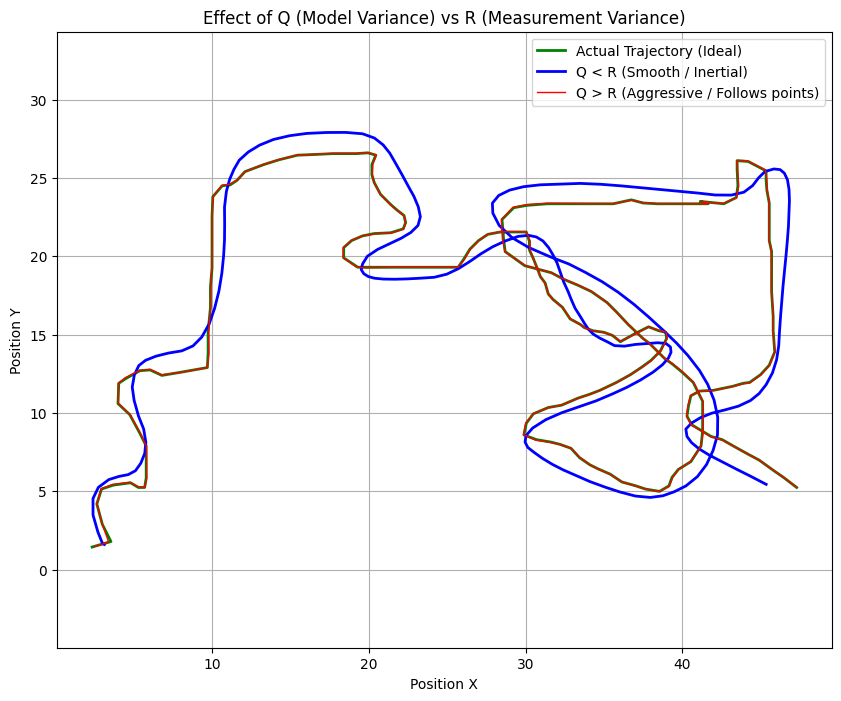

In [13]:

# mu_0 — Initial state: first position, initial velocity = 0
mu_0 = np.array([5, 2, 0.0, 0.0])

# P_0 — Initial covariance (high uncertainty in velocity)
P_0 = np.diag([2.0, 2.0, 10.0, 10.0])

# Scenery A: Q (0.01) < R (5.0) (We trust the model / softens a lot)
est_soft = custom_kalmanFilter(observations[:,0], observations[:,1], 0.01, 5.0, H, A, P_0, mu_0)

# Scenery B: Q (5.0) > R (1.0) (We trust the meassurement / Reacts faster)
est_hard = custom_kalmanFilter(observations[:,0], observations[:,1], 5.0, 1.0, H, A, P_0, mu_0)

# Graph the results
plt.figure(figsize=(10, 8))
plt.plot(observations[:,0], observations[:,1], 'g-', label='Actual Trajectory (Ideal)', linewidth=2)
plt.plot(est_soft[:, 0], est_soft[:, 1], 'blue', label='Q < R (Smooth / Inertial)', linewidth=2)
plt.plot(est_hard[:, 0], est_hard[:, 1], 'red', label='Q > R (Aggressive / Follows points)', linewidth=1)
plt.legend()
plt.title("Effect of Q (Model Variance) vs R (Measurement Variance)")
plt.xlabel("Position X")
plt.ylabel("Position Y")
plt.axis('equal')
plt.grid(True)
plt.show()

On the previous graph we can se that the Blue Line (where Q<R) we obtain an elegant and smooth prediction. In this case we can see that the model is able to eliminate almost all noise, however we can notice that on curves it deviates from the actual trajectory because its inertia is stronger than what the points indicate.

On the other hand, the red Line (where Q>R) We can see that the model follows each noisy point almost perfectly. There's no lag on curves, but the trajectory is "nervous" because it doesn't filter out sensor error.

As for the convergence of the filter, we can say that both converge, but the red line does so instantly towards the data, while the blue line takes a few steps to stabilize its internal speed.

In [14]:
# Extract only the (X, Y) positions from the estimates
pos_soft = est_soft[:, [0, 1]]     
pos_hard = est_hard[:, [0, 1]]

# Calculate MSE for each case
mse_soft = mean_squared_error(observations, pos_soft)
mse_hard = mean_squared_error(observations, pos_hard)

print(f"MSE Smooth filter (Q < R):     {mse_soft:.4f}")
print(f"MSE Aggrsive filter (Q > R):   {mse_hard:.4f}")

MSE Smooth filter (Q < R):     1.4246
MSE Aggrsive filter (Q > R):   0.0006


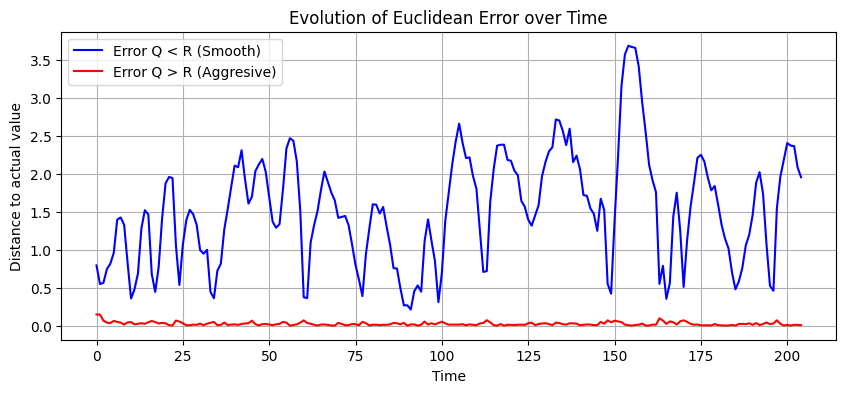

In [15]:
# Calculate Euclidean error point by point
err_soft = np.sqrt(np.sum((observations - pos_soft)**2, axis=1))
err_hard = np.sqrt(np.sum((observations - pos_hard)**2, axis=1))

plt.figure(figsize=(10, 4))
plt.plot(err_soft, label='Error Q < R (Smooth)', color='blue')
plt.plot(err_hard, label='Error Q > R (Aggresive)', color='red')
plt.title("Evolution of Euclidean Error over Time")
plt.ylabel("Distance to actual value")
plt.xlabel("Time")
plt.legend()
plt.grid(True)
plt.show()

In the previous graph we can see that the "Aggressive Filter" (Q > R) the model converges to the sensor error almost immediately because it relies too much on the sensor, so it "copies" the noise instead of filtering it.

While in the "Soft Filter" (Q < R) the filter appear to have become "deaf" to the measurements. In this case, even if the sensor is telling the truth (the object changed direction), the filter believes the sensor is lying and sticks to its inertial prediction. For this case, the Kalman Gain becomes almost zero.

In this case, we can see that even if the model has converged in both cases the error is high but stable when Q < R, the filter converged to a model that does not match reality (tuning error).


---
## Changing the parameters

Now that we understand the process, we will be changing the parameters of the kalman filter to obtain three different scenarios where the model can estimate the meassurements very close, where they're not close, and where the model doesn't have a good efficiency.

To achieve the three scenarios, we must adjust the relationship between the Model Variance ($Q$) and the Measurement Variance ($R$). These two variables control the Kalman Gain ($K$), which dictates how much the filter trusts its own predictions against the sensor data.

* In the first case, we must use a small measurement variace (R) which represents a model with low noise, and a small model variance (Q) wich represents a system that closely follows the laws of physics.

* For the second case, both the measurement variance (R) and the model variance (Q) must be big, meaning a sensor with high noise and an unreliable model or the object moves erratically.

* In the last case, we will have a filter that is "over-smoothed", ignoring the reality of the data. To achieve this, the meassurement variance (R) must be big so we tell the filter not to trust the sensor, even though the sensor is actually good.


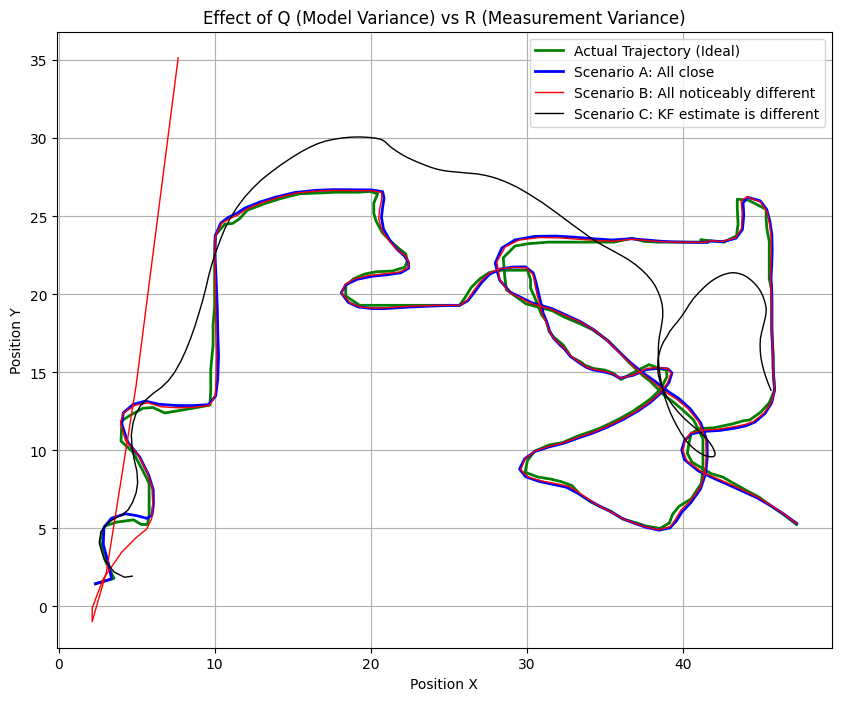

In [16]:
# mu_0 — Initial state: first position, initial velocity = 0
mu_0 = np.array([5, 2, 0.0, 0.0])

# P_0 — Initial covariance (high uncertainty in velocity)
P_0 = np.diag([2.0, 2.0, 10.0, 10.0])

# Scenario A: Measurements, KF estimate and true value are all close
kalman_A = custom_kalmanFilter(observations[:,0], observations[:,1], 0.01, 0.1, H, A, P_0, mu_0)

# Scenario B: Measurements, KF estimate and true value are all noticeably different.

kalman_B = custom_kalmanFilter(observations[:,0], observations[:,1], 10.0, 50.0, H, A, P_0, [10, 50, 0.0, 0.0])

# Scenario C: The measurements are close to the true value, but the KF estimate is different.
kalman_C = custom_kalmanFilter(observations[:,0], observations[:,1], 0.0001, 100.0, H, A, P_0, mu_0)

# Graph the results
plt.figure(figsize=(10, 8))
plt.plot(observations[:,0], observations[:,1], 'g-', label='Actual Trajectory (Ideal)', linewidth=2)
plt.plot(kalman_A[:, 0], kalman_A[:, 1], 'blue', label='Scenario A: All close', linewidth=2)
plt.plot(kalman_B[:, 0], kalman_B[:, 1], 'red', label='Scenario B: All noticeably different', linewidth=1)
plt.plot(kalman_C[:, 0], kalman_C[:, 1], 'black', label='Scenario C: KF estimate is different', linewidth=1)
plt.legend()
plt.title("Effect of Q (Model Variance) vs R (Measurement Variance)")
plt.xlabel("Position X")
plt.ylabel("Position Y")
plt.axis('equal')
plt.grid(True)
plt.show()

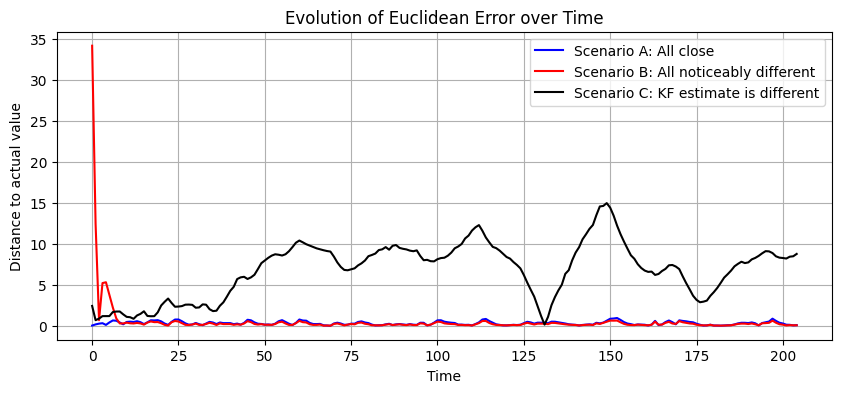

In [17]:
# Calculate Euclidean error point by point
err_A = np.sqrt(np.sum((observations - kalman_A)**2, axis=1))
err_B = np.sqrt(np.sum((observations - kalman_B)**2, axis=1))
err_C = np.sqrt(np.sum((observations - kalman_C)**2, axis=1))

plt.figure(figsize=(10, 4))
plt.plot(err_A, label='Scenario A: All close', color='blue')
plt.plot(err_B, label='Scenario B: All noticeably different', color='red')
plt.plot(err_C, label='Scenario C: KF estimate is different', color='black')
plt.title("Evolution of Euclidean Error over Time")
plt.ylabel("Distance to actual value")
plt.xlabel("Time")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# Extract only the (X, Y) positions from the estimates
pos_A = kalman_A[:, [0, 1]]     
pos_B = kalman_B[:, [0, 1]]
pos_C = kalman_C[:, [0, 1]]

# Calculate MSE for each case
mse_A = mean_squared_error(observations, pos_A)
mse_B = mean_squared_error(observations, pos_B)
mse_C = mean_squared_error(observations, pos_C)

print(f"MSE Scenario A: All close:                  {mse_A:.4f}")
print(f"MSE Scenario B: All noticeably different:   {mse_B:.4f}")
print(f"MSE Scenario C: KF estimate is different:   {mse_C:.4f}")

MSE Scenario A: All close:                  0.0703
MSE Scenario B: All noticeably different:   3.4357
MSE Scenario C: KF estimate is different:   28.7124


As a result we obtain, in the first case, a model in which the actual value is closely tracked by the sensor, and the filter, seeing that both match, generates a near-perfect estimate with a balanced Kalman Gain. As a result the MSE is the smallest of all and the error along the time is small. For the second case, we can see that the measurements jump at the begining of the graph, and then the filter is able to reach a value similar to the measure, not trusting either the model or the sensor, wanders before converging. In the last case, the filter has a Kalman Gain close to 0. This causes the filter to ignore the actual data and remain "stuck" to its initial prediction or inertial model, moving very slowly towards the target or following an incorrect trajectory.